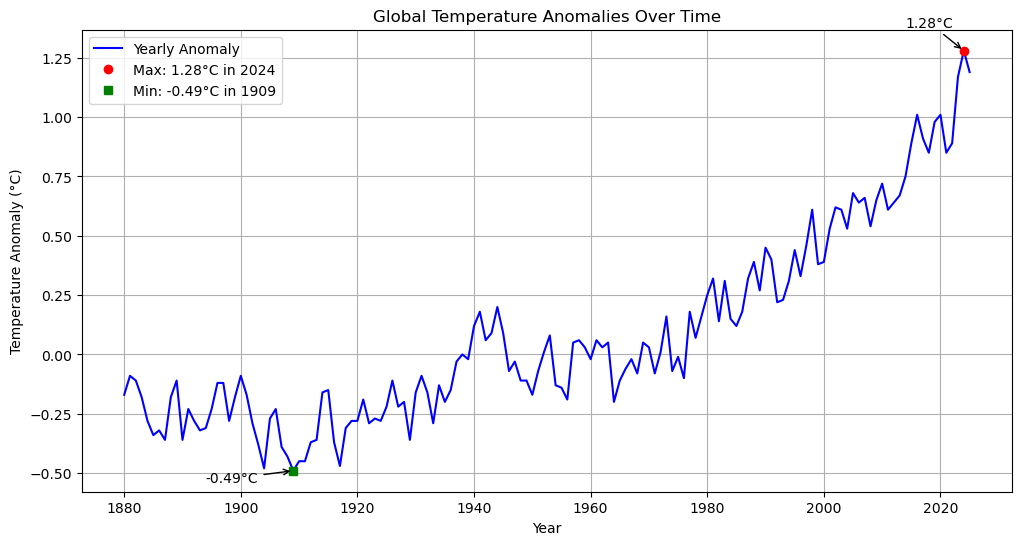

In [21]:
import csv
import logging
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - %(levelname)s - %(message)s'
)

def load_temperature_csv(filename):
    """Load NASA GISTEMP CSV into a list of dictionaries."""
    
    data = []  # We'll store each row as a dictionary
    
    try:
        with open(filename, 'r') as file:
            next(file)     #Skips first row in csv file, which contains a header, not column names
            reader = csv.DictReader(file)
            
            for row in reader:  # Process each row one by one
                
                # Step 1: Convert Year to integer safely
                try:
                    row['Year'] = int(row['Year'])
                except ValueError:
                    row['Year'] = None  # If invalid, mark as None
                
                # Step 2: Convert J-D (yearly anomaly) to float safely
                try:
                    row['J-D'] = float(row['J-D'])
                except ValueError:
                    row['J-D'] = None  # If invalid, mark as None
                
                # Step 3: Append the processed row to the data list
                data.append(row)
    
    except FileNotFoundError:      #Logs an error if file can't be opened
        logging.error(f"File {filename} not found")
        return []
    
    if not data:                   #Logs an error if dataset is empty
        logging.warning(f"No valid data found in {filename}")
    
    return data     #Stores the loaded and converted data as 'data'

temperature_data = load_temperature_csv("temperature_anomalies.csv")


anomalies = []

for record in temperature_data:

    value = record['J-D']

    if value is not None:
        anomalies.append(value)

def compute_average(values):
    """Calculates the average temperature anomaly."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average

def find_max_anomaly(dataset):
    """Calculates the maxiumum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    max_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if max_record is None or value > max_record['J-D']:
            max_record = record

    return max_record    

max_record = find_max_anomaly(temperature_data)


def find_min_anomaly(dataset):
    """Calculates the minimum temperature anomaly."""
    if len(dataset) == 0:     #If the list is empty retrun None
        return None

    min_record = None

    for record in dataset:
        value = record['J-D']

        #If value is None(record in dataset is corrupt or missing) skip this record
        if value is None:
            continue

        if min_record is None or value < min_record['J-D']:
            min_record = record

    return min_record



def plot_temperature_trend(dataset):
    """Plots time_series of global temp anomalies using Matplotlib"""
    """ with highlighted max and min points"""
    
    years = []       #Two lists to hold x-axis and y-axis values
    anomalies = []

    for record in dataset:

        value = record['J-D']   #Extract the anomaly value

        if value is None:       #Skip missing values
            continue

        years.append(record['Year'])    #Add values to the lists
        anomalies.append(value)

    #Get max and min records
    max_record = find_max_anomaly(dataset)
    min_record = find_min_anomaly(dataset)

    max_year = max_record['Year']
    max_value = max_record['J-D']
    
    min_year = min_record['Year']
    min_value = min_record['J-D']

    #Create the plot, using Matplotlib
    plt.figure(figsize=(12,6))    #Controls size of plot window, if not included there is a default size

    #Line plot of anomalies
    plt.plot(years, anomalies, label='Yearly Anomaly', color='blue')   #Line label in legend, color = line colour

    #Max anomaly plot
    plt.plot(max_year, max_value, 'ro', label=f'Max: {max_value}°C in {max_year}') #Adds marker at max value 'ro' = red circle

    plt.annotate(f'{max_value}°C', xy=(max_year, max_value),        #Adds a pont for the max anomaly value
             xytext=(max_year-10, max_value+0.1),                   #Determines where the spot's label will appear
             arrowprops=dict(facecolor='black', arrowstyle='->'))   #Deterimes colour and style of arrow

    # Min anomaly point
    plt.plot(min_year, min_value, 'gs', label=f'Min: {min_value}°C in {min_year}')   #Adds marker at min value 'gs' = green square
    plt.annotate(f'{min_value}°C',
                 xy=(min_year, min_value),
                 xytext=(min_year-15, min_value-0.05),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

    #Labels, legeng, grid
    plt.xlabel("Year")                                  #x-axis label
    plt.ylabel("Temperature Anomaly (°C)")              #y-axis label
    plt.title("Global Temperature Anomalies Over Time") #Graph title
    plt.grid(True)                                      #Shows gridlines
    plt.legend()                                        #Shows legend
    
    plt.show()                                          #Display the plot

plot_temperature_trend(temperature_data)
    

In [8]:
print(f"Loaded {len(temperature_data)} records")
print(temperature_data[:5])  # Show first 5 rows to check

Loaded 147 records
[{'Year': 1880, 'Jan': '-0.19', 'Feb': '-0.25', 'Mar': '-0.09', 'Apr': '-0.16', 'May': '-0.1', 'Jun': '-0.21', 'Jul': '-0.18', 'Aug': '-0.1', 'Sep': '-0.14', 'Oct': '-0.23', 'Nov': '-0.22', 'Dec': '-0.19', 'J-D': -0.17, 'D-N': '***', 'DJF': '***', 'MAM': '-0.12', 'JJA': '-0.17', 'SON': '-0.2'}, {'Year': 1881, 'Jan': '-0.2', 'Feb': '-0.15', 'Mar': '0.02', 'Apr': '0.04', 'May': '0.07', 'Jun': '-0.19', 'Jul': '0.01', 'Aug': '-0.04', 'Sep': '-0.15', 'Oct': '-0.21', 'Nov': '-0.18', 'Dec': '-0.07', 'J-D': -0.09, 'D-N': '-0.1', 'DJF': '-0.18', 'MAM': '0.04', 'JJA': '-0.07', 'SON': '-0.18'}, {'Year': 1882, 'Jan': '0.16', 'Feb': '0.14', 'Mar': '0.04', 'Apr': '-0.16', 'May': '-0.14', 'Jun': '-0.23', 'Jul': '-0.16', 'Aug': '-0.08', 'Sep': '-0.15', 'Oct': '-0.23', 'Nov': '-0.17', 'Dec': '-0.36', 'J-D': -0.11, 'D-N': '-0.09', 'DJF': '0.08', 'MAM': '-0.09', 'JJA': '-0.16', 'SON': '-0.18'}, {'Year': 1883, 'Jan': '-0.29', 'Feb': '-0.36', 'Mar': '-0.12', 'Apr': '-0.18', 'May': '-0.18

In [27]:
print(len(anomalies))
print(anomalies[:10])

146
[-0.17, -0.09, -0.11, -0.18, -0.28, -0.34, -0.32, -0.36, -0.18, -0.11]


In [11]:
avg = compute_average(anomalies)
print("Average anomaly:", avg)

Average anomaly: 0.08041095890410968


In [31]:
max_record = find_max_anomaly(temperature_data)
print(max_record)
print("Highest anomaly year:", max_record['Year'])
print("Anomaly value:", max_record['J-D'])

{'Year': 2024, 'Jan': '1.25', 'Feb': '1.43', 'Mar': '1.39', 'Apr': '1.31', 'May': '1.16', 'Jun': '1.24', 'Jul': '1.2', 'Aug': '1.3', 'Sep': '1.23', 'Oct': '1.34', 'Nov': '1.29', 'Dec': '1.26', 'J-D': 1.28, 'D-N': '1.29', 'DJF': '1.34', 'MAM': '1.29', 'JJA': '1.25', 'SON': '1.29'}
Highest anomaly year: 2024
Anomaly value: 1.28


In [24]:
min_record = find_min_anomaly(temperature_data)

print("Lowest anomaly year:", min_record['Year'])
print("Anomaly value:", min_record['J-D'])

Lowest anomaly year: 1909
Anomaly value: -0.49
